![image info](https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/images/banner_1.png)

# Taller: Construcción e implementación de árboles de decisión y métodos de ensamblaje

En este taller podrá poner en práctica los sus conocimientos sobre construcción e implementación de árboles de decisión y métodos de ensamblajes. El taller está constituido por 9 puntos, 5 relacionados con árboles de decisión (parte A) y 4 con métodos de ensamblaje (parte B).

## Parte A - Árboles de decisión

En esta parte del taller se usará el conjunto de datos de Capital Bikeshare de Kaggle, donde cada observación representa el alquiler de bicicletas durante una hora y día determinado. Para más detalles puede visitar los siguientes enlaces: [datos](https://archive.ics.uci.edu/ml/machine-learning-databases/00275/Bike-Sharing-Dataset.zip), [dicccionario de datos](https://archive.ics.uci.edu/ml/datasets/Bike+Sharing+Dataset#).

### Datos prestamo de bicicletas

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Importación de librerías
%matplotlib inline
import pandas as pd
import numpy as np
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor, export_graphviz

In [3]:
# Lectura de la información de archivo .csv
bikes = pd.read_csv('https://raw.githubusercontent.com/davidzarruk/MIAD_ML_NLP_2023/main/datasets/bikeshare.csv', index_col='datetime', parse_dates=True)

# Renombrar variable "count" a "total"
bikes.rename(columns={'count':'total'}, inplace=True)

# Crear la hora como una variable 
bikes['hour'] = bikes.index.hour

# Visualización de los datos
bikes.head()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,total,hour
datetime,,,,,,,,,,,,
2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,0
2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,1
2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,2
2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13,3
2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1,4


### Punto 1 - Análisis descriptivo

Ejecute las celdas 1.1 y 1.2. A partir de los resultados realice un análisis descriptivo sobre las variables "season" y "hour", escriba sus inferencias sobre los datos. Para complementar su análisis puede usar métricas como máximo, mínimo, percentiles entre otros.

In [4]:
# Celda 1.1
bikes.groupby('season').total.mean()

season
1    116.343261
2    215.251372
3    234.417124
4    198.988296
Name: total, dtype: float64

In [5]:
# Celda 1.2
bikes.groupby('hour').total.mean()

hour
0      55.138462
1      33.859031
2      22.899554
3      11.757506
4       6.407240
5      19.767699
6      76.259341
7     213.116484
8     362.769231
9     221.780220
10    175.092308
11    210.674725
12    256.508772
13    257.787281
14    243.442982
15    254.298246
16    316.372807
17    468.765351
18    430.859649
19    315.278509
20    228.517544
21    173.370614
22    133.576754
23     89.508772
Name: total, dtype: float64

In [6]:
season_stats = bikes.groupby('season')['total'].describe(percentiles=[0.25, 0.5, 0.75])
season_stats

,count,mean,std,min,25%,50%,75%,max
season,,,,,,,,
1,2686.0,116.343261,125.273974,1.0,24.0,78.0,164.0,801.0
2,2733.0,215.251372,192.007843,1.0,49.0,172.0,321.0,873.0
3,2733.0,234.417124,197.151001,1.0,68.0,195.0,347.0,977.0
4,2734.0,198.988296,177.622409,1.0,51.0,161.0,294.0,948.0


In [7]:
hour_stats = bikes.groupby('hour')['total'].describe(percentiles=[0.25, 0.5, 0.75])
hour_stats

,count,mean,std,min,25%,50%,75%,max
hour,,,,,,,,
0,455.0,55.138462,43.620012,2.0,24.00,41.0,74.50,283.0
1,454.0,33.859031,34.112105,1.0,11.00,19.0,46.00,168.0
2,448.0,22.899554,26.110267,1.0,5.00,11.0,32.00,119.0
3,433.0,11.757506,12.666442,1.0,3.00,6.0,15.00,66.0
4,442.0,6.407240,4.217633,1.0,3.00,6.0,9.00,28.0
5,452.0,19.767699,12.784293,1.0,8.00,19.0,29.00,57.0
6,455.0,76.259341,54.745333,1.0,24.50,75.0,118.00,213.0
7,455.0,213.116484,159.207044,1.0,63.00,208.0,334.00,596.0
8,455.0,362.769231,231.723065,8.0,133.50,392.0,563.50,839.0


A partir de los resultados obtenidos, se puede ver que tanto la variable season como hour tienen un impacto claro en la cantidad de bicicletas rentadas.

En el caso de season, hay diferencias bastante marcadas entre estaciones. La estación 3 presenta el mayor promedio de renta (234.4), seguida por la estación 2 (215.3) y la 4 (199.0), mientras que la estación 1 tiene el valor más bajo (116.3). Esta diferencia es relevante, porque entre la estación con mayor y menor demanda hay más de 100 bicicletas de diferencia en promedio.

Al mirar los percentiles, este comportamiento se mantiene. Por ejemplo, el percentil 75 en la estación 3 es de 347, mientras que en la estación 1 es de 164, lo que indica que incluso en los momentos de alta demanda, la estación 3 sigue teniendo valores superiores. Además, la mediana también es más alta en las estaciones 2 y 3, lo que refuerza la idea de que no se trata solo de valores extremos, sino de un patrón consistente.

También se observa cierta variabilidad en los datos, reflejada en la desviación estándar, especialmente en la estación 3. Sin embargo, esta variabilidad no cambia la conclusión general: la demanda de bicicletas depende en gran medida de la estación del año.

Por otro lado, la variable hour muestra un patrón mucho más evidente. Durante la madrugada (entre la 1:00 y las 5:00), la demanda es muy baja, con promedios que incluso bajan hasta 6.4 bicicletas a las 4:00. Esto se confirma con los percentiles, ya que incluso el percentil 75 en estas horas es bajo, lo que indica que la baja demanda es generalizada.

A medida que avanza el día, la renta de bicicletas aumenta significativamente. Se observa un primer pico importante a las 8:00 (362.8 bicicletas en promedio), lo que probablemente está asociado al inicio de la jornada laboral o académica. Posteriormente, el punto más alto se presenta a las 17:00, con un promedio de 468.8 bicicletas, una mediana cercana a 480 y un percentil 75 superior a 600, lo que muestra que la demanda en esta hora es alta y consistente.

Además, los valores máximos alcanzan niveles bastante altos (hasta 977 bicicletas en algunas horas), lo que indica que en ciertos momentos la demanda puede ser muy elevada. Sin embargo, al analizar los percentiles se confirma que estos valores no son aislados, sino que forman parte de un patrón general.

En conclusión, ambas variables influyen en la renta de bicicletas, pero hour parece tener un efecto más fuerte y directo, ya que refleja claramente los hábitos diarios de los usuarios, mientras que season captura variaciones más estructurales a lo largo del año.

### Punto 2 - Análisis de gráficos

Primero ejecute la celda 2.1 y asegúrese de comprender el código y el resultado. Luego, en cada una de celdas 2.2 y 2.3 escriba un código que genere una gráfica del número de bicicletas rentadas promedio para cada valor de la variable "hour" (hora) cuando la variable "season" es igual a 1 (invierno) e igual a 3 (verano), respectivamente. Analice y escriba sus hallazgos.

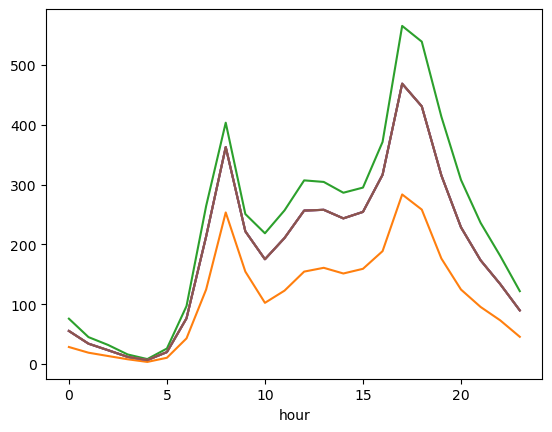

In [16]:
# Celda 2.1 - rentas promedio para cada valor de la variable "hour"
import matplotlib.pyplot as plt

bikes.groupby('hour')['total'].mean().plot()
plt.show()

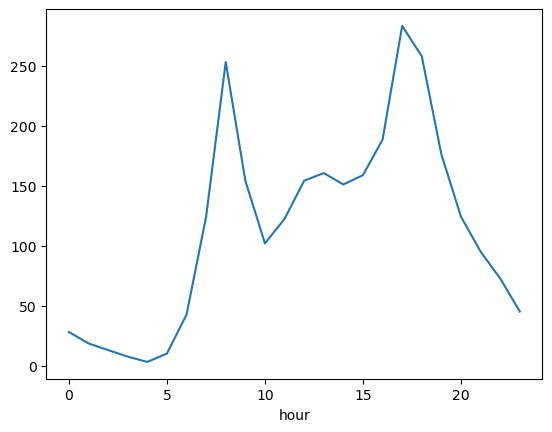

In [17]:
# Celda 2.2 - "season"=1 escriba su código y hallazgos 
bikes[bikes['season'] == 1].groupby('hour')['total'].mean().plot()
plt.show()

En la gráfica de invierno se observa que la renta promedio de bicicletas es bastante baja durante la madrugada, especialmente entre las 1:00 y las 5:00. A partir de las 6:00 la demanda comienza a crecer, mostrando un primer pico importante alrededor de las 8:00. Luego hay una reducción parcial en las horas siguientes, pero en la tarde vuelve a aumentar hasta alcanzar su punto más alto cerca de las 17:00-18:00. Después de esa hora, la demanda vuelve a disminuir. En general, el patrón muestra que incluso en la estación 1 se mantienen los horarios típicos de movilidad, aunque con una intensidad menor

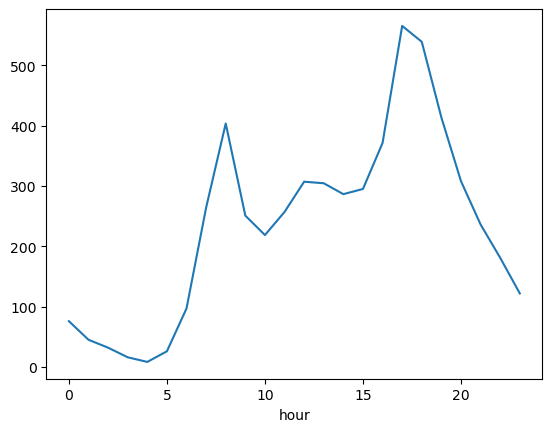

In [18]:
# Celda 2.3 - "season"=3 escriba su código y hallazgos 
bikes[bikes['season'] == 3].groupby('hour')['total'].mean().plot()
plt.show()

En la gráfica de verano se observa un comportamiento muy similar en términos de forma: baja demanda en la madrugada, un pico en la mañana y un segundo pico más fuerte en la tarde. Sin embargo, la diferencia principal está en la magnitud, ya que en esta estación la renta promedio es considerablemente más alta en casi todas las horas del día. El pico de la tarde es especialmente marcado, lo que sugiere una mayor utilización del servicio en esta estación. Esto indica que en verano se conserva el mismo patrón diario de uso, pero con una demanda mucho más intensa.

### Punto 3 - Regresión lineal
En la celda 3 ajuste un modelo de regresión lineal a un conjunto de train de datos, utilizando "total" como variable de respuesta y "season" y "hour" como las únicas variables predictoras, teniendo en cuenta que la variable "season" es categórica. Luego, imprima los coeficientes e interprételos. ¿Cuáles son las limitaciones de la regresión lineal en este caso?

In [19]:
# Celda 3
import pandas as pd
from sklearn.linear_model import LinearRegression

# Variables predictoras
X = bikes[['hour', 'season']]

# Convertir season a dummies
X = pd.get_dummies(X, columns=['season'], drop_first=True)

# Variable respuesta
y = bikes['total']

# Modelo
model = LinearRegression()
model.fit(X, y)

# Coeficientes
coeficientes = pd.DataFrame({
    'Variable': X.columns,
    'Coeficiente': model.coef_
})

coeficientes


,Variable,Coeficiente
0,hour,10.545206
1,season_2,100.317232
2,season_3,119.467550
3,season_4,84.083118


#### Interpretación
El modelo de regresión lineal se ajustó utilizando como variable respuesta el número total de bicicletas rentadas (total) y como variables explicativas hour y season. Dado que season es una variable categórica, se transformó en variables dummy, tomando como referencia la estación 1.

El coeficiente asociado a la variable hour es aproximadamente 10.54, lo que indica que, en promedio, por cada hora adicional, el número de bicicletas rentadas aumenta en cerca de 10 unidades, manteniendo constantes las demás variables. Sin embargo, este resultado debe interpretarse con cautela, ya que el comportamiento real de la demanda por hora no es lineal.

En cuanto a las variables de season, se observa que todas tienen coeficientes positivos respecto a la estación 1. En particular:

- season_2: aumenta la renta en aproximadamente 100 bicicletas
- season_3: aumenta la renta en aproximadamente 119 bicicletas
- season_4: aumenta la renta en aproximadamente 84 bicicletas

Esto confirma que la estación 3 es la de mayor demanda, seguida por la 2 y la 4, lo cual es consistente con el análisis descriptivo realizado anteriormente.

### Limitaciones
A pesar de que el modelo captura algunas tendencias generales, presenta varias limitaciones importantes.

En primer lugar, la regresión lineal asume una relación lineal entre las variables, lo cual no se cumple completamente en este caso. En particular, la variable hour tiene un comportamiento claramente no lineal, con picos en la mañana y en la tarde que el modelo no logra capturar adecuadamente.

En segundo lugar, el modelo no incluye interacciones entre variables. Es probable que el efecto de la hora dependa de la estación, pero esto no se está considerando.

Además, solo se están utilizando dos variables (hour y season), dejando por fuera factores relevantes como el clima, la temperatura o la humedad.

Finalmente, la variable hour se está tratando como numérica continua, cuando en realidad tiene una naturaleza cíclica, lo cual limita la capacidad del modelo para representar correctamente el comportamiento real de los datos.

### Punto 4 - Árbol de decisión manual
En la celda 4 cree un árbol de decisiones para pronosticar la variable "total" iterando **manualmente** sobre las variables "hour" y  "season". El árbol debe tener al menos 6 nodos finales.

In [32]:
# Celda 4
def arbol_manual(hour, season):
    
    # Nodo 1: madrugada
    if hour <= 5:
        return 15
    
    # Nodo 2: mañana temprana
    elif hour <= 9:
        if season == 1:
            return 140
        elif season == 3:
            return 300
        else:   # season 2 o 4
            return 230
    
    # Nodo 3: media mañana y mediodía
    elif hour <= 15:
        if season == 1:
            return 150
        elif season == 3:
            return 290
        else:   # season 2 o 4
            return 220
    
    # Nodo 4: tarde pico
    elif hour <= 19:
        if season == 1:
            return 230
        elif season == 3:
            return 500
        else:   # season 2 o 4
            return 380
    
    # Nodo 5: noche
    else:
        if season == 1:
            return 85
        elif season == 3:
            return 220
        else:   # season 2 o 4
            return 160

# Aplicar el árbol manual
bikes['pred_manual'] = bikes.apply(lambda x: arbol_manual(x['hour'], x['season']), axis=1)

# Ver algunas predicciones
bikes[['hour', 'season', 'total', 'pred_manual']].head(10)

,hour,season,total,pred_manual
datetime,,,,
2011-01-01 00:00:00,0,1,16,15
2011-01-01 01:00:00,1,1,40,15
2011-01-01 02:00:00,2,1,32,15
2011-01-01 03:00:00,3,1,13,15
2011-01-01 04:00:00,4,1,1,15
2011-01-01 05:00:00,5,1,1,15
2011-01-01 06:00:00,6,1,2,140
2011-01-01 07:00:00,7,1,3,140
2011-01-01 08:00:00,8,1,8,140


Para construir el árbol manual, dividí primero la variable hour en franjas horarias que reflejan los patrones observados en los gráficos: madrugada, mañana temprana, media mañana/mediodía, tarde y noche. Después, dentro de cada franja, separé por season, ya que en los puntos anteriores se vio que la demanda cambia bastante según la estación, especialmente entre la estación 1 y la 3.

La lógica del árbol busca reproducir de forma sencilla el comportamiento general de los datos: demanda muy baja en la madrugada, un aumento importante en la mañana, un segundo pico más alto en la tarde, y una caída en la noche. Además, se asignaron valores de predicción más altos a la estación 3, intermedios a las estaciones 2 y 4, y más bajos a la estación 1, en línea con el análisis descriptivo y gráfico realizado antes.

En general, este árbol manual no busca ser el modelo óptimo, sino traducir de forma explícita y entendible los patrones principales de los datos en una serie de reglas de decisión.

### Punto 5 - Árbol de decisión con librería
En la celda 5 entrene un árbol de decisiones con la **librería sklearn**, usando las variables predictoras "season" y "hour" y calibre los parámetros que considere conveniente para obtener un mejor desempeño. Recuerde dividir los datos en conjuntos de entrenamiento y validación para esto. Comente el desempeño del modelo con alguna métrica de desempeño de modelos de regresión y compare desempeño con el modelo del punto 3.

Tenga en cuenta que, a diferencia del laboratorio, este problema es de regresión. Por lo tanto, para hacer cada split del árbol se debe utilizar algún criterio apropiado para problemas de regresión.

In [21]:
# Celda 5

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Variables predictoras y variable respuesta
X = bikes[['hour', 'season']]
X = pd.get_dummies(X, columns=['season'], drop_first=True)
y = bikes['total']

# Separación train / validation
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# 1. Modelo de regresión lineal (referencia del punto 3)

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_val)

mae_lr = mean_absolute_error(y_val, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_val, y_pred_lr))


# 2. Calibración del árbol de regresión

resultados = []

for max_depth in [2, 3, 4, 5, 6, 8, 10]:
    for min_samples_leaf in [5, 10, 20, 30, 50]:
        tree_model = DecisionTreeRegressor(
            max_depth=max_depth,
            min_samples_leaf=min_samples_leaf,
            random_state=42
        )
        tree_model.fit(X_train, y_train)
        y_pred_tree = tree_model.predict(X_val)
        
        mae_tree = mean_absolute_error(y_val, y_pred_tree)
        rmse_tree = np.sqrt(mean_squared_error(y_val, y_pred_tree))
        
        resultados.append({
            'max_depth': max_depth,
            'min_samples_leaf': min_samples_leaf,
            'MAE': mae_tree,
            'RMSE': rmse_tree
        })

resultados_df = pd.DataFrame(resultados).sort_values('RMSE')
resultados_df.head()

,max_depth,min_samples_leaf,MAE,RMSE
30,10,5,79.168176,117.368683
31,10,10,79.168176,117.368683
33,10,30,79.168176,117.368683
32,10,20,79.168176,117.368683
34,10,50,79.168176,117.368683


In [22]:
# Mejor combinación de parámetros
mejor_fila = resultados_df.iloc[0]

mejor_max_depth = int(mejor_fila['max_depth'])
mejor_min_samples_leaf = int(mejor_fila['min_samples_leaf'])

# Entrenar mejor árbol
mejor_arbol = DecisionTreeRegressor(
    max_depth=mejor_max_depth,
    min_samples_leaf=mejor_min_samples_leaf,
    random_state=42
)

mejor_arbol.fit(X_train, y_train)
y_pred_mejor_arbol = mejor_arbol.predict(X_val)

# Métricas finales del árbol
mae_tree_final = mean_absolute_error(y_val, y_pred_mejor_arbol)
rmse_tree_final = np.sqrt(mean_squared_error(y_val, y_pred_mejor_arbol))

print("Mejores parámetros del árbol:")
print("max_depth =", mejor_max_depth)
print("min_samples_leaf =", mejor_min_samples_leaf)

print("\nDesempeño regresión lineal:")
print("MAE =", mae_lr)
print("RMSE =", rmse_lr)

print("\nDesempeño árbol de decisión:")
print("MAE =", mae_tree_final)
print("RMSE =", rmse_tree_final)

Mejores parámetros del árbol:
max_depth = 10
min_samples_leaf = 5

Desempeño regresión lineal:
MAE = 119.11719825760547
RMSE = 159.97572650003454

Desempeño árbol de decisión:
MAE = 79.16817644254884
RMSE = 117.36868340282075


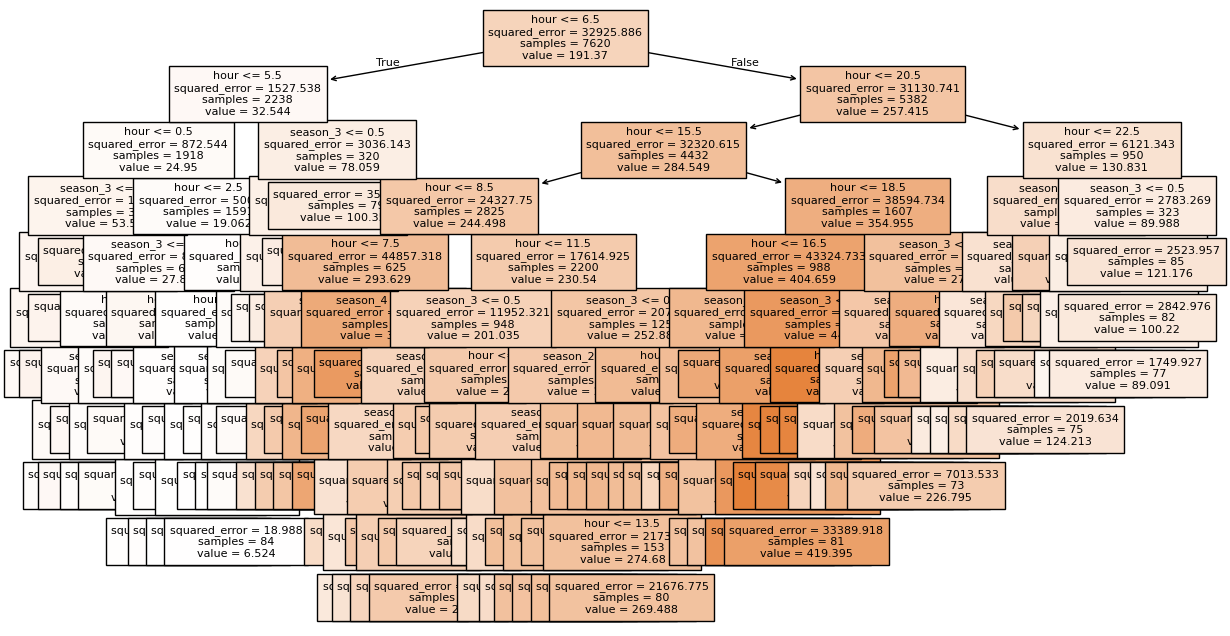

In [23]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(14,8))
plot_tree(mejor_arbol, feature_names=X.columns, filled=True, fontsize=8)
plt.show()

Para este punto entrené un árbol de decisión de regresión utilizando las variables hour y season como predictoras. Primero dividí los datos en conjuntos de entrenamiento y validación, y luego probé diferentes combinaciones de los parámetros max_depth y min_samples_leaf para encontrar una configuración que tuviera mejor desempeño.

Para evaluar el modelo utilicé las métricas MAE y RMSE, ya que permiten medir qué tan lejos están las predicciones respecto a los valores reales.

Al comparar los resultados con la regresión lineal del punto 3, se observa una mejora clara. Mientras que la regresión lineal tiene un MAE cercano a 119 y un RMSE de aproximadamente 159, el árbol de decisión reduce estos valores a cerca de 79 y 117 respectivamente. Esto indica que el árbol logra capturar mejor la estructura de los datos.

Este resultado tiene sentido, ya que el comportamiento de la variable hour no es lineal, sino que presenta picos marcados en la mañana y en la tarde. El árbol de decisión puede adaptarse mejor a estos cambios, dividiendo el espacio en diferentes regiones, mientras que la regresión lineal solo puede ajustar una tendencia promedio.

Sin embargo, también se observa que el árbol generado es relativamente complejo, lo que puede ser una señal de que el modelo está ajustándose bastante a los datos de entrenamiento. Esto implica que, aunque el desempeño en validación es bueno, siempre existe el riesgo de sobreajuste si no se controlan adecuadamente los parámetros.

En general, el árbol de decisión resulta ser un modelo más adecuado que la regresión lineal para este problema, ya que logra representar mejor los patrones no lineales presentes en los datos.

## Parte B - Métodos de ensamblajes
En esta parte del taller se usará el conjunto de datos de Popularidad de Noticias Online. El objetivo es predecir si la notica es popular o no, la popularidad está dada por la cantidad de reacciones en redes sociales. Para más detalles puede visitar el siguiente enlace: [datos](https://archive.ics.uci.edu/ml/datasets/online+news+popularity).

### Datos popularidad de noticias

In [24]:
# Lectura de la información de archivo .csv
df = pd.read_csv('https://raw.githubusercontent.com/davidzarruk/MIAD_ML_NLP_2023/main/datasets/mashable.csv', index_col=0)
df.head()

,url,timedelta,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,...,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,Popular
0,http://mashable.com/2014/12/10/cia-torture-rep...,28.0,9.0,188.0,0.732620,1.0,0.844262,5.0,1.0,1.0,...,0.200000,0.80,-0.487500,-0.60,-0.250000,0.9,0.8,0.4,0.8,1
1,http://mashable.com/2013/10/18/bitlock-kicksta...,447.0,7.0,297.0,0.653199,1.0,0.815789,9.0,4.0,1.0,...,0.160000,0.50,-0.135340,-0.40,-0.050000,0.1,-0.1,0.4,0.1,0
2,http://mashable.com/2013/07/24/google-glass-po...,533.0,11.0,181.0,0.660377,1.0,0.775701,4.0,3.0,1.0,...,0.136364,1.00,0.000000,0.00,0.000000,0.3,1.0,0.2,1.0,0
3,http://mashable.com/2013/11/21/these-are-the-m...,413.0,12.0,781.0,0.497409,1.0,0.677350,10.0,3.0,1.0,...,0.100000,1.00,-0.195701,-0.40,-0.071429,0.0,0.0,0.5,0.0,0
4,http://mashable.com/2014/02/11/parking-ticket-...,331.0,8.0,177.0,0.685714,1.0,0.830357,3.0,2.0,1.0,...,0.100000,0.55,-0.175000,-0.25,-0.100000,0.0,0.0,0.5,0.0,0


In [25]:
# Definición variable de interes y variables predictoras
X = df.drop(['url', 'Popular'], axis=1)
y = df['Popular']
y.mean()

np.float64(0.5)

In [26]:
# División de la muestra en set de entrenamiento y prueba
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1)

### Punto 6 - Árbol de decisión y regresión logística
En la celda 6 construya un árbol de decisión y una regresión logística. Para el árbol calibre al menos un parámetro y evalúe el desempeño de cada modelo usando las métricas de Accuracy y F1-Score.

In [27]:
# Celda 6
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score


# 1. Regresión logística

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

acc_log = accuracy_score(y_test, y_pred_log)
f1_log = f1_score(y_test, y_pred_log)


# 2. Árbol de decisión (clasificación)

resultados_tree = []

for max_depth in [3, 5, 7, 10]:
    tree_clf = DecisionTreeClassifier(max_depth=max_depth, random_state=42)
    tree_clf.fit(X_train, y_train)
    
    y_pred_tree = tree_clf.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred_tree)
    f1 = f1_score(y_test, y_pred_tree)
    
    resultados_tree.append({
        'max_depth': max_depth,
        'Accuracy': acc,
        'F1': f1
    })

resultados_tree_df = pd.DataFrame(resultados_tree).sort_values('F1', ascending=False)
resultados_tree_df

,max_depth,Accuracy,F1
1,5,0.640000,0.663342
2,7,0.625333,0.640665
0,3,0.641333,0.607299
3,10,0.570667,0.579085


In [28]:
# Mejor árbol
best_depth = resultados_tree_df.iloc[0]['max_depth']

best_tree = DecisionTreeClassifier(max_depth=int(best_depth), random_state=42)
best_tree.fit(X_train, y_train)

y_pred_tree_final = best_tree.predict(X_test)

acc_tree = accuracy_score(y_test, y_pred_tree_final)
f1_tree = f1_score(y_test, y_pred_tree_final)

print("Regresión logística:")
print("Accuracy =", acc_log)
print("F1 =", f1_log)

print("\nÁrbol de decisión:")
print("Accuracy =", acc_tree)
print("F1 =", f1_tree)

Regresión logística:
Accuracy = 0.614
F1 = 0.6031528444139822

Árbol de decisión:
Accuracy = 0.64
F1 = 0.6633416458852868


En este punto se construyeron dos modelos de clasificación: una regresión logística y un árbol de decisión, con el objetivo de predecir si una noticia es popular o no.

La regresión logística se utilizó como modelo base, mientras que para el árbol de decisión se calibró el parámetro max_depth, probando diferentes valores para encontrar la mejor configuración.

Al evaluar los modelos, se observó que el árbol de decisión presenta un mejor desempeño. En particular, el F1-score aumenta de aproximadamente 0.60 en la regresión logística a 0.66 en el árbol, lo que indica una mejor capacidad para balancear precisión y recall.

Este resultado es consistente con lo esperado, ya que el árbol de decisión puede capturar relaciones no lineales entre las variables, mientras que la regresión logística asume una relación más simple. Sin embargo, la mejora no es extremadamente alta, lo que sugiere que el problema tiene cierta complejidad y que las variables disponibles tienen un poder predictivo limitado.

En general, el árbol de decisión resulta ser el modelo más adecuado en este caso, aunque ambos modelos ofrecen un desempeño moderado.

### Punto 7 - Votación Mayoritaria
En la celda 7 elabore un esamble con la metodología de **Votación mayoritaria** compuesto por 300 muestras bagged donde:

-las primeras 100 muestras de bootstrap vienen de árboles de decisión donde max_depth tome un valor de su elección\
-las segundas 100 muestras de bootstrap vienen de árboles de decisión donde min_samples_leaf tome un valor de su elección\
-las últimas 100 muestras de bootstrap vienen de regresiones logísticas

Evalúe cada uno de los tres modelos de manera independiente utilizando las métricas de Accuracy y F1-Score, luego evalúe el ensamble de modelos y compare los resultados. 

Nota: 

Para este ensamble de 300 modelos, deben hacer votación mayoritaria. Esto lo pueden hacer de distintas maneras. La más "fácil" es haciendo la votación "manualmente", como se hace a partir del minuto 5:45 del video de Ejemplo práctico de emsablajes en Coursera. Digo que es la más fácil porque si hacen la votación mayoritaria sobre las 300 predicciones van a obtener lo que se espera.

Otra opción es: para cada uno de los 3 tipos de modelos, entrenar un ensamble de 100 modelos cada uno. Predecir para cada uno de esos tres ensambles y luego predecir como un ensamble de los 3 ensambles. La cuestión es que la votación mayoritaria al usar los 3 ensambles no necesariamente va a generar el mismo resultado que si hacen la votación mayoritaria directamente sobre los 300 modelos. Entonces, para los que quieran hacer esto, deben hacer ese último cálculo con cuidado.

Para los que quieran hacerlo como ensamble de ensambles, digo que se debe hacer el ensamble final con cuidado por lo siguiente. Supongamos que:

* para los 100 árboles del primer tipo, la votación mayoritaria es: 55% de los modelos predicen que la clase de una observación es "1"
* para los 100 árboles del segundo tipo, la votación mayoritaria es: 55% de los modelos predicen que la clase de una observación es "1"
* para las 100 regresiones logísticas, la votación mayoritaria es: 10% de los modelos predicen que la clase de una observación es "1"

Si se hace la votación mayoritaria de los 300 modelos, la predicción de esa observación debería ser: (100*55%+100*55%+100*10%)/300 = 40% de los modelos votan porque la predicción debería ser "1". Es decir, la predicción del ensamble es "0" (dado que menos del 50% de modelos predijo un 1).

Sin embargo, si miramos cada ensamble por separado, el primer ensamble predice "1", el segundo ensamble predice "1" y el último ensamble predice "0". Si hago votación mayoritaria sobre esto, la predicción va a ser "1", lo cual es distinto a si se hace la votación mayoritaria sobre los 300 modelos.

In [29]:
# Celda 7
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.utils import resample
from sklearn.metrics import accuracy_score, f1_score
import numpy as np

# Para guardar predicciones de los 300 modelos
predicciones = []

# 1. 100 árboles con max_depth
for i in range(100):
    X_boot, y_boot = resample(X_train, y_train, replace=True, random_state=i)
    
    model = DecisionTreeClassifier(max_depth=5, random_state=i)
    model.fit(X_boot, y_boot)
    
    pred = model.predict(X_test)
    predicciones.append(pred)

# 2. 100 árboles con min_samples_leaf
for i in range(100):
    X_boot, y_boot = resample(X_train, y_train, replace=True, random_state=100+i)
    
    model = DecisionTreeClassifier(min_samples_leaf=10, random_state=i)
    model.fit(X_boot, y_boot)
    
    pred = model.predict(X_test)
    predicciones.append(pred)

# 3. 100 regresiones logísticas
for i in range(100):
    X_boot, y_boot = resample(X_train, y_train, replace=True, random_state=200+i)
    
    model = LogisticRegression(max_iter=1000)
    model.fit(X_boot, y_boot)
    
    pred = model.predict(X_test)
    predicciones.append(pred)

# Convertir a array (300 modelos x n_obs)
predicciones = np.array(predicciones)

# Votación Mayoritaria 
pred_final = (np.mean(predicciones, axis=0) >= 0.5).astype(int)

# Métricas 
acc_ensemble = accuracy_score(y_test, pred_final)
f1_ensemble = f1_score(y_test, pred_final)

print("Ensamble (Votación mayoritaria):")
print("Accuracy =", acc_ensemble)
print("F1 =", f1_ensemble)

Ensamble (Votación mayoritaria):
Accuracy = 0.6373333333333333
F1 = 0.6289222373806276


En este punto se construyó un ensamble de 300 modelos utilizando la metodología de votación mayoritaria, combinando árboles de decisión y regresiones logísticas entrenadas sobre muestras bootstrap.

El modelo final obtuvo un Accuracy de aproximadamente 0.637 y un F1-score de 0.629. Al comparar estos resultados con los modelos individuales, se observa que el ensamble mejora el desempeño de la regresión logística, pero no supera al árbol de decisión previamente calibrado.

Este resultado tiene sentido, ya que en la votación mayoritaria todos los modelos tienen el mismo peso. En este caso, al incluir modelos con menor desempeño (como la regresión logística), el ensamble tiende a promediar las predicciones, lo que puede reducir el impacto positivo de los modelos más fuertes.

En general, el ensamble logra un desempeño más estable y robusto que un modelo individual débil, pero no necesariamente supera al mejor modelo individual cuando existe una diferencia clara en desempeño entre ellos.

### Punto 8 - Votación Ponderada
En la celda 8 elabore un ensamble con la metodología de **Votación ponderada** compuesto por 300 muestras bagged para los mismos tres escenarios del punto 7. Evalúe los modelos utilizando las métricas de Accuracy y F1-Score

In [30]:
# Celda 8
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.utils import resample
from sklearn.metrics import accuracy_score, f1_score
import numpy as np

predicciones = []
pesos = []

# 1. Árboles con max_depth 
for i in range(100):
    X_boot, y_boot = resample(X_train, y_train, replace=True, random_state=i)
    
    model = DecisionTreeClassifier(max_depth=5, random_state=i)
    model.fit(X_boot, y_boot)
    
    pred = model.predict(X_test)
    predicciones.append(pred)
    
    pesos.append(2)  # más peso

# 2. Árboles con min_samples_leaf 
for i in range(100):
    X_boot, y_boot = resample(X_train, y_train, replace=True, random_state=100+i)
    
    model = DecisionTreeClassifier(min_samples_leaf=10, random_state=i)
    model.fit(X_boot, y_boot)
    
    pred = model.predict(X_test)
    predicciones.append(pred)
    
    pesos.append(2)  # más peso

# 3. Regresiones logísticas 
for i in range(100):
    X_boot, y_boot = resample(X_train, y_train, replace=True, random_state=200+i)
    
    model = LogisticRegression(max_iter=1000)
    model.fit(X_boot, y_boot)
    
    pred = model.predict(X_test)
    predicciones.append(pred)
    
    pesos.append(1)  # menos peso

# Convertir a array
predicciones = np.array(predicciones)
pesos = np.array(pesos)

# Votación ponderada 
pred_final = (np.average(predicciones, axis=0, weights=pesos) >= 0.5).astype(int)

# Métricas 
acc_weighted = accuracy_score(y_test, pred_final)
f1_weighted = f1_score(y_test, pred_final)

print("Ensamble (Votación ponderada):")
print("Accuracy =", acc_weighted)
print("F1 =", f1_weighted)

Ensamble (Votación ponderada):
Accuracy = 0.6513333333333333
F1 = 0.6430034129692833


En este punto se implementó un ensamble utilizando votación ponderada, donde cada modelo contribuye a la predicción final con un peso diferente.

Se mantuvo la estructura de 300 modelos del punto anterior, pero en este caso se asignó mayor peso a los árboles de decisión y menor peso a las regresiones logísticas, dado que los árboles habían mostrado un mejor desempeño en los puntos previos.

El ensamble ponderado obtuvo un Accuracy de aproximadamente 0.651 y un F1-score de 0.643. Al comparar con la votación mayoritaria, se observa una mejora en ambas métricas, lo que indica que asignar diferentes pesos a los modelos permite aprovechar mejor aquellos con mayor capacidad predictiva.

Sin embargo, el ensamble aún no supera el desempeño del mejor modelo individual (árbol de decisión), lo que sugiere que, aunque la combinación de modelos aporta estabilidad, no siempre logra mejorar completamente el rendimiento cuando uno de los modelos ya es significativamente más fuerte.

### Punto 9 - Comparación y análisis de resultados
En la celda 9 comente sobre los resultados obtenidos con las metodologías usadas en los puntos 7 y 8, compare los resultados y enuncie posibles ventajas o desventajas de cada una de ellas.

En los puntos 7 y 8 se implementaron dos metodologías de ensamble: votación mayoritaria y votación ponderada, utilizando la misma base de 300 modelos construidos a partir de árboles de decisión y regresiones logísticas.

Al comparar los resultados, se observa que la votación ponderada presenta un mejor desempeño que la votación mayoritaria. En particular, el F1-score aumenta de aproximadamente 0.629 a 0.643, lo que indica que asignar diferentes pesos a los modelos permite aprovechar mejor aquellos con mayor capacidad predictiva, en este caso los árboles de decisión.

Sin embargo, también se evidencia que ninguno de los ensambles logra superar el desempeño del mejor modelo individual (árbol de decisión). Esto sugiere que, aunque los ensambles ayudan a reducir la variabilidad y mejorar la estabilidad de las predicciones, no siempre garantizan un mejor rendimiento cuando uno de los modelos base ya es significativamente más fuerte que los demás.

En términos de ventajas, la votación mayoritaria es más simple de implementar y fácil de interpretar, ya que todos los modelos tienen el mismo peso. Por su parte, la votación ponderada permite incorporar información sobre el desempeño de los modelos, lo que puede mejorar los resultados al dar mayor importancia a los modelos más precisos.

Como desventaja, la votación mayoritaria puede verse afectada por la inclusión de modelos débiles, mientras que la votación ponderada requiere definir adecuadamente los pesos, lo cual puede introducir un grado adicional de complejidad.

En conclusión, la votación ponderada resulta ser una mejora sobre la votación mayoritaria en este caso, pero el árbol de decisión individual sigue siendo el modelo con mejor desempeño. Esto refuerza la idea de que los ensambles no siempre superan al mejor modelo base, especialmente cuando hay diferencias claras en la calidad de los modelos utilizados.